In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import get_data as gd

In [2]:
# ---------------------------
# Helpers: generar ruido y upsampling conv generator (DIP)
# ---------------------------
def make_generator(input_shape=(32, 32, 32), out_channels=1, base_filters=64):
    """
    Generador simple tipo encoder-decoder (sin skip connections para simplicidad)
    input_shape: shape del ruido de entrada (H_noise, W_noise, C_noise)
    salida: mapa (N, M, out_channels)
    """
    inp = layers.Input(shape=input_shape)

    x = inp
    # encoder
    x = layers.Conv2D(base_filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(base_filters, 3, padding='same', activation='relu')(x)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    x = layers.Conv2D(base_filters*2, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(base_filters*2, 3, padding='same', activation='relu')(x)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    x = layers.Conv2D(base_filters*4, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(base_filters*4, 3, padding='same', activation='relu')(x)

    # decoder (upsample)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(base_filters*2, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(base_filters*2, 3, padding='same', activation='relu')(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(base_filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(base_filters, 3, padding='same', activation='relu')(x)

    # salida: 1 canal
    out = layers.Conv2D(out_channels, 1, padding='same', activation='linear')(x)

    model = Model(inputs=inp, outputs=out)
    return model

# ---------------------------
# Pérdidas auxiliares
# ---------------------------
def boundary_mask_from_row_col(n, m, row0, col0):
    mask = np.zeros((n, m), dtype=np.float32)
    mask[0, :] = 1.0
    mask[:, 0] = 1.0
    return mask

def total_variation_loss(x):
    # x: tensor shape (batch,H,W,1)
    dh = tf.abs(x[:, 1:, :, :] - x[:, :-1, :, :])
    dw = tf.abs(x[:, :, 1:, :] - x[:, :, :-1, :])
    return tf.reduce_mean(dh) + tf.reduce_mean(dw)

# ---------------------------
# Entrenamiento DIP
# ---------------------------
def run_dip(cheap, boundary_row, boundary_col,
            noise_shape=(32,32,32),
            iters=5000,
            lr=1e-3,
            weight_cheap_inside=0.1,
            weight_tv=1e-4,
            print_every=200):
    """
    cheap: matriz (n,m) con el método barato
    boundary_row: primera fila del MC real (m,)
    boundary_col: primera columna del MC real (n,)
    Devuelve la matriz reconstruida (n,m) y el historial de pérdida.
    """

    n, m = cheap.shape
    cheap = cheap.astype(np.float32)

    # armado de ground-truth parcial (solo frontera)
    boundary = np.zeros((n, m), dtype=np.float32)
    boundary[0, :] = boundary_row
    boundary[:, 0] = boundary_col
    mask = boundary_mask_from_row_col(n, m, boundary_row, boundary_col).astype(np.float32)

    # normalizamos por el max absolute para estabilidad
    global_max = max(np.max(np.abs(cheap)), np.max(np.abs(boundary)), 1.0)
    cheap_n = cheap / global_max
    boundary_n = boundary / global_max
    mask_n = mask  # mask es 0/1, no escala

    # crear modelo
    gen = make_generator(input_shape=noise_shape, out_channels=1, base_filters=64)
    # nota: la salida del gen debe tener la forma aproximada (H_out, W_out)
    # si el generador produce la misma resolución: ok. sino, usaremos resize.
    # aqui asumimos que la salida espacial coincide con la forma cheap (n,m).
    # Para garantizarlo, forzamos resize al tamaño (n,m) después de la red.
    optimizer = optimizers.Adam(learning_rate=lr)

    # ruido de entrada fijo (se puede añadir jitter durante entrenamiento)
    z = np.random.normal(size=(1, noise_shape[0], noise_shape[1], noise_shape[2])).astype(np.float32)

    # placeholder para historial
    history = {'loss_total': [], 'loss_boundary': [], 'loss_cheap': [], 'loss_tv': []}
    best_loss = np.inf
    best_pred = None
    patience = 800
    wait = 0

    for it in range(1, iters + 1):
        # opcional: añadir pequeño ruido al input (jitter)
        z_jitter = z + 0.03 * np.random.normal(size=z.shape).astype(np.float32)

        with tf.GradientTape() as tape:
            out = gen(z_jitter, training=True)  # (1, H_gen, W_gen, 1)
            # Redimensionar a (1, n, m, 1) si es necesario
            out_resized = tf.image.resize(out, (n, m), method='bilinear')
            # normalizar? el generador produce valores libres, los dejamos así y trabajamos con escala global
            # pérdidas:
            # boundary loss: MSE solo en máscara (batch-wise)
            diff = out_resized[0, :, :, 0] - boundary_n
            loss_boundary = tf.reduce_sum(tf.square(diff * mask_n)) / (tf.reduce_sum(mask_n) + 1e-8)

            # cheap inside loss: MSE interior (donde mask==0) entre salida y cheap_n
            diff_inside = out_resized[0, :, :, 0] - cheap_n
            loss_cheap = tf.reduce_sum(tf.square(diff_inside * (1.0 - mask_n))) / (tf.reduce_sum(1.0 - mask_n) + 1e-8)

            loss_tv = total_variation_loss(out_resized)

            loss = loss_boundary + weight_cheap_inside * loss_cheap + weight_tv * loss_tv

        grads = tape.gradient(loss, gen.trainable_variables)
        optimizer.apply_gradients(zip(grads, gen.trainable_variables))

        # guardar historial
        history['loss_total'].append(float(loss.numpy()))
        history['loss_boundary'].append(float(loss_boundary.numpy()))
        history['loss_cheap'].append(float(loss_cheap.numpy()))
        history['loss_tv'].append(float(loss_tv.numpy()))

        # early stopping tipo "guardar mejor"
        if history['loss_boundary'][-1] < best_loss:
            best_loss = history['loss_boundary'][-1]
            best_pred = out_resized.numpy()[0, :, :, 0].copy()
            wait = 0
        else:
            wait += 1

        # printing
        if it % print_every == 0 or it == 1:
            print(f"it {it:05d} | loss={history['loss_total'][-1]:.6e} "
                  f"| bnd={history['loss_boundary'][-1]:.6e} cheap={history['loss_cheap'][-1]:.6e} tv={history['loss_tv'][-1]:.6e}")

        # criterio simple de parada por paciencia en mejora de boundary
        if wait > patience:
            print("Stop por paciencia (no mejora boundary).")
            break

    # reconstrucción final (re-escala)
    if best_pred is None:
        out_final = out_resized.numpy()[0, :, :, 0]
    else:
        out_final = best_pred

    # reescalamos al espacio original
    out_final = out_final * global_max

    # forzamos valores exactos en la frontera (por si acaso)
    out_final[mask == 1] = boundary[mask == 1]

    return out_final, history

In [3]:
def run_dip_partial_boundary(cheap, boundary, mask,
                             noise_shape=(32,32,16),
                             iters=5000,
                             lr=1e-3,
                             weight_cheap_inside=0.1,
                             weight_tv=1e-4,
                             print_every=200):
    """
    cheap: matriz barata completa (n,m)
    boundary: matriz con valores conocidos de frontera, resto 0 (n,m)
    mask: máscara de frontera muestreada (1 en puntos conocidos, 0 en el resto) (n,m)
    """
    n, m = cheap.shape
    cheap = cheap.astype(np.float32)
    boundary = boundary.astype(np.float32)
    mask = mask.astype(np.float32)

    # normalización global para estabilidad
    global_max = max(np.max(np.abs(cheap)), np.max(np.abs(boundary)), 1.0)
    cheap_n = cheap / global_max
    boundary_n = boundary / global_max
    mask_n = mask

    # crear modelo
    gen = make_generator(input_shape=noise_shape, out_channels=1, base_filters=64)
    optimizer = optimizers.Adam(learning_rate=lr)

    # ruido de entrada fijo
    z = np.random.normal(size=(1, noise_shape[0], noise_shape[1], noise_shape[2])).astype(np.float32)

    # historial
    history = {'loss_total': [], 'loss_boundary': [], 'loss_cheap': [], 'loss_tv': []}
    best_loss = np.inf
    best_pred = None
    patience = 800
    wait = 0

    for it in range(1, iters+1):
        # jitter opcional
        z_jitter = z + 0.03 * np.random.normal(size=z.shape).astype(np.float32)

        with tf.GradientTape() as tape:
            out = gen(z_jitter, training=True)  # (1,H,W,1)
            # redimensionar a (n,m)
            out_resized = tf.image.resize(out, (n,m), method='bilinear')
            # pérdidas
            diff_boundary = out_resized[0,:,:,0] - boundary_n
            loss_boundary = tf.reduce_sum(tf.square(diff_boundary * mask_n)) / (tf.reduce_sum(mask_n) + 1e-8)

            diff_inside = out_resized[0,:,:,0] - cheap_n
            loss_cheap = tf.reduce_sum(tf.square(diff_inside * (1.0 - mask_n))) / (tf.reduce_sum(1.0 - mask_n) + 1e-8)

            loss_tv = total_variation_loss(out_resized)
            loss = loss_boundary + weight_cheap_inside * loss_cheap + weight_tv * loss_tv

        grads = tape.gradient(loss, gen.trainable_variables)
        optimizer.apply_gradients(zip(grads, gen.trainable_variables))

        # historial
        history['loss_total'].append(float(loss.numpy()))
        history['loss_boundary'].append(float(loss_boundary.numpy()))
        history['loss_cheap'].append(float(loss_cheap.numpy()))
        history['loss_tv'].append(float(loss_tv.numpy()))

        # guardar mejor predicción según pérdida de frontera
        if history['loss_boundary'][-1] < best_loss:
            best_loss = history['loss_boundary'][-1]
            best_pred = out_resized.numpy()[0,:,:,0].copy()
            wait = 0
        else:
            wait += 1

        if it % print_every == 0 or it==1:
            print(f"it {it:05d} | loss={loss.numpy():.6e} "
                  f"| bnd={loss_boundary.numpy():.6e} cheap={loss_cheap.numpy():.6e} tv={loss_tv.numpy():.6e}")

        if wait > patience:
            print("Early stopping por paciencia.")
            break

    # reconstrucción final
    if best_pred is None:
        out_final = out_resized.numpy()[0,:,:,0]
    else:
        out_final = best_pred

    out_final = out_final * global_max
    # forzar valores conocidos
    out_final[mask==1] = boundary[mask==1]

    return out_final, history

In [5]:
df = pd.read_csv("SOC_matrix_g-2.csv", header=None)  # usa la primera columna como índice
SOC_matrix = df.values

In [6]:
path = './datos_sqr-2/'
coord, soc, params = gd.get_points(path)

In [8]:
n, m = SOC_matrix.shape


known_points = coord

# error_points = [(96,82), (88,75), (60,85), (73,88), (84,89), (67,92),
#                 (79,94), (96,95), (66,96), (86,96), (82,97), (70,97),
#                 (98,98), (80,102), (76,108), (72,111)]


known_values = soc


# error_values = [
#     0.181244, 0.349721, 0.947943, 0.872449, 0.64845,
#     0.923514, 0.787521, 0.219049, 0.942591, 0.58311,
#     0.714847, 0.913074, 0.181051, 0.777656, 0.865875,
#     0.908687
# ]

# crear máscara y boundary
mask = np.zeros((n,m), dtype=np.float32)
boundary = np.zeros((n,m), dtype=np.float32)

for (i,j), val in zip(known_points, known_values):
    mask[i,j] = 1.0
    boundary[i,j] = val

# cheap (puede ser suavizado de SOC_matrix o calculado con método rápido)
cheap = SOC_matrix.copy()  # o algún aproximado

# ejecutar DIP
recon, hist = run_dip_partial_boundary(cheap, boundary, mask,
                                       noise_shape=(32,32,16),
                                       iters=3000,
                                       lr=1e-3)

W0000 00:00:1761159084.611814   11512 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


it 00001 | loss=2.689607e-01 | bnd=2.271968e-01 cheap=4.176375e-01 tv=1.154898e-03
it 00200 | loss=1.357587e-04 | bnd=1.654219e-06 cheap=1.327541e-03 tv=1.350449e-02
it 00400 | loss=1.139986e-04 | bnd=1.809492e-05 cheap=9.457379e-04 tv=1.329901e-02
it 00600 | loss=1.839830e-04 | bnd=1.089982e-04 cheap=7.361646e-04 tv=1.368317e-02
it 00800 | loss=9.979554e-05 | bnd=3.311540e-05 cheap=6.532554e-04 tv=1.354597e-02
it 01000 | loss=8.297284e-05 | bnd=1.401693e-05 cheap=6.762657e-04 tv=1.329334e-02
it 01200 | loss=7.256997e-05 | bnd=1.545637e-05 cheap=5.576332e-04 tv=1.350271e-02
it 01400 | loss=5.836068e-05 | bnd=5.177133e-06 cheap=5.183563e-04 tv=1.347917e-02
Early stopping por paciencia.


In [9]:
pts = np.array(params)

# noval = np.array([[-2.016, -0.268], [-1.354, 0.11], [-1.354, -1.402], [-1.685, -0.835]])

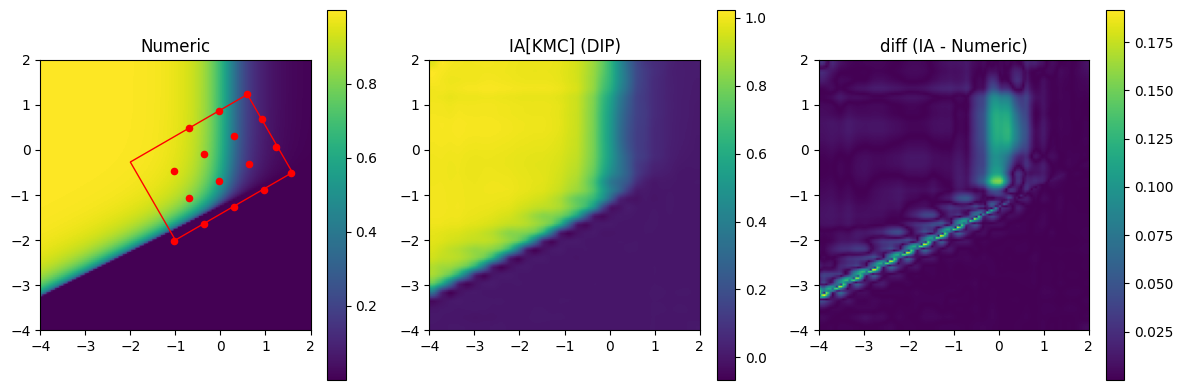

In [10]:
plt.figure(figsize=(12,4))
extent = [-4, 2, -4, 2]
x0, y0 = -1., -2.    
lado = 2 

# Primer panel
ax1 = plt.subplot(1,3,1)
ax1.set_title('Numeric')
im1 = ax1.imshow(cheap.T, origin='lower', extent=extent)
ax1.scatter(pts[:,0], pts[:,1], color='red', s=20)
# ax1.scatter(noval[:,0], noval[:,1], color='green', s=20)
rect = patches.Rectangle(
    (x0, y0), 1.5*lado, lado,
    linewidth=1, edgecolor='red', facecolor='none', angle=30
)
ax1.add_patch(rect)
plt.colorbar(im1, ax=ax1)

# Segundo panel
ax2 = plt.subplot(1,3,2)
ax2.set_title('IA[KMC] (DIP)')
im2 = ax2.imshow(recon.T, origin='lower', extent=extent)
plt.colorbar(im2, ax=ax2)

# Tercer panel
ax3 = plt.subplot(1,3,3)
ax3.set_title('diff (IA - Numeric)')
im3 = ax3.imshow(np.abs(recon - cheap).T, origin='lower', extent=extent)
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()

In [16]:
error = np.sqrt(np.sum([np.abs(recon[erp] - erv)**2 for erp, erv in zip(error_points, error_values)])/(len(error_values) - 1))

In [17]:
error

0.011429112293975889